Part3:

Use the Animal10 dataset in moodle to repeat the experiment. See also the Kaggle
page.\
a)

Download images to your computer and load the data organized as training and
testing data (use 20% for testing).\
Explore and visualize some of the data to gain a better understanding of the problem.\
You can use tensorflow's image_dataset_from_directory function and other standard functions to scale the dataset to the same input sizes, etc...\
b)

Explore the dataset.\
Visualize some images, check image sizes, number of images in each folder.\
c)

Perform operations to achieve a balanced dataset (use undersampling or data
augmentation).\
d)

Construct a Convolutional Neural Network to predict the correct label, and train it.\
Tune the structure and hyperparameters for best accuracy.\
Visualize accuracy over the training epochs.

In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# unzip the dataset into a working directory
!unzip /content/drive/MyDrive/Animals10.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/raw-img/ragno/OIP-MgrKq05YHGXsgj1AmYIyJQHaE8.jpeg  
  inflating: /content/raw-img/ragno/OIP-MhRGx7d8nbnHBuqrsO00E

In [3]:
import os
import random

data_dir = "/content/raw-img"

# Get class folders
class_names = sorted(os.listdir(data_dir))
class_paths = [os.path.join(data_dir, c) for c in class_names]

In [4]:
# Count images per class
class_image_counts = {}
for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    images = os.listdir(class_folder)
    class_image_counts[class_name] = len(images)

In [5]:
# Find smallest class size
min_class_size = min(class_image_counts.values())
print("Smallest class size:", min_class_size)

Smallest class size: 1446


In [6]:
# Remove extra images from larger classes. we are using Undersampling to balance the dataset.
for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    images = os.listdir(class_folder)

    if len(images) > min_class_size:
        images_to_remove = random.sample(
            images,
            len(images) - min_class_size
        )

        for img in images_to_remove:
            os.remove(os.path.join(class_folder, img))

In [7]:
import keras
img_height = 128
img_width = 128
batch_size = 32

# build training data
(animals10_train, animals10_test) = keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="both",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 14460 files belonging to 10 classes.
Using 11568 files for training.
Using 2892 files for validation.


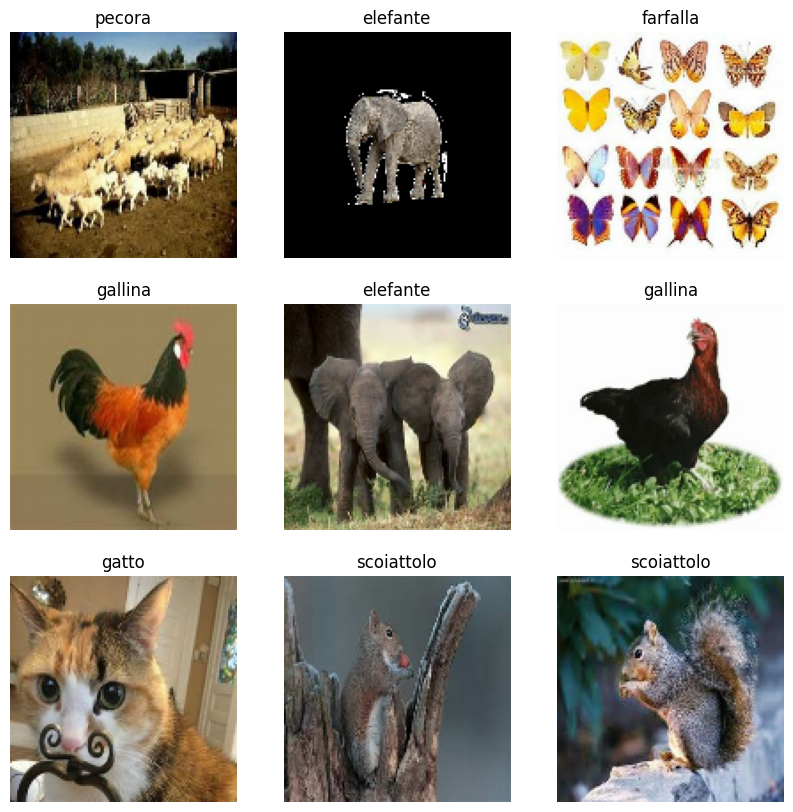

In [25]:
# display a few of the images (explore the dataset)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in animals10_train.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [123]:
from keras import datasets, layers, models

# construct a CNN to predict the image labels
modelA = models.Sequential()
modelA.add(layers.InputLayer(input_shape=(128, 128, 3)))
modelA.add(layers.Rescaling(1./255))

# augmentation
modelA.add(layers.RandomFlip('horizontal'))
modelA.add(layers.RandomRotation(0.01))
#modelA.add(layers.RandomZoom(0.1))

# added the convolutional layers
modelA.add(layers.Conv2D(32, (3, 3)))
modelA.add(layers.BatchNormalization())
modelA.add(layers.Activation('relu'))
modelA.add(layers.Conv2D(32, (3, 3)))
modelA.add(layers.BatchNormalization())
modelA.add(layers.Activation('relu'))
modelA.add(layers.MaxPooling2D((2, 2)))


modelA.add(layers.Conv2D(64, (3, 3)))
modelA.add(layers.BatchNormalization())
modelA.add(layers.Activation('relu'))
modelA.add(layers.MaxPooling2D((2, 2)))
modelA.add(layers.Conv2D(64, (3, 3)))
modelA.add(layers.BatchNormalization())
modelA.add(layers.Activation('relu'))
modelA.add(layers.MaxPooling2D((2, 2)))


modelA.add(layers.Conv2D(128, (3, 3)))
modelA.add(layers.BatchNormalization())
modelA.add(layers.Activation('relu'))
# modelA.add(layers.Conv2D(128, (3, 3)))
# modelA.add(layers.BatchNormalization())
# modelA.add(layers.Activation('relu'))
modelA.add(layers.MaxPooling2D((2, 2)))

# flatten
modelA.add(layers.Flatten())

# fully connected layers
modelA.add(layers.Dense(256, activation='relu'))
modelA.add(layers.Dropout(0.2))
modelA.add(layers.Dense(10))

In [126]:
import keras

# compile the model
modelA.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])


In [127]:
# display the model
modelA.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_26 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_7 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_9               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_149 (Conv2D)             │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_131         │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_138 (Activation)     │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_150 (Conv2D)             │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_132         │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_139 (Activation)     │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_133         │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_140 (Activation)     │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_134         │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_141 (Activation)     │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_153 (Conv2D)             │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_135         │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_142 (Activation)     │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 6, 6, 128)      │             

 Total params: 1,323,178 (5.05 MB)

 Trainable params: 1,322,538 (5.05 MB)

 Non-trainable params: 640 (2.50 KB)

In [137]:
# train the model
historyA = modelA.fit(animals10_train, epochs=10, validation_data=animals10_test)

Epoch 1/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.9150 - loss: 0.2459 - val_accuracy: 0.7624 - val_loss: 0.9825
Epoch 2/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.9174 - loss: 0.2283 - val_accuracy: 0.7344 - val_loss: 1.1405
Epoch 3/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.9115 - loss: 0.2420 - val_accuracy: 0.7254 - val_loss: 1.1921
Epoch 4/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9178 - loss: 0.2318 - val_accuracy: 0.7293 - val_loss: 1.2077
Epoch 5/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9200 - loss: 0.2227 - val_accuracy: 0.7320 - val_loss: 1.2393
Epoch 6/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.9185 - loss: 0.2279 - val_accuracy: 0.7628 - val_loss: 1.0646
Epoch 7/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9252 - loss: 0.2127 - val_accuracy: 0.7189 - val_loss: 1.3901
Epoch 8/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.9282 - loss: 0.1993 - 

In [135]:
modelA.save("/content/Prg2_Part3.keras")

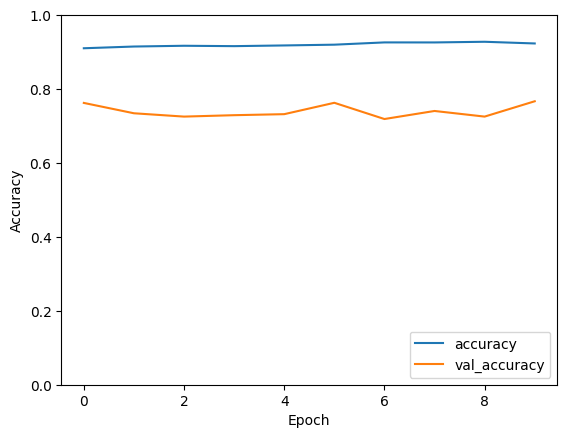

In [138]:
# evaluate the model's accuracy
plt.plot(historyA.history['accuracy'], label='accuracy')
plt.plot(historyA.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right')

#test_lossA, test_accA = model100.evaluate(x_test100,  y_test100, verbose=2)